<a href="https://colab.research.google.com/github/Isadora220825/PSP-8---An-lise-Delivery-Pares-Tradicional-vs-IA/blob/main/Trabalho_PSP_8_Isadora_Messenberg_(231013387)_An%C3%A1lise_Delivery_Pares_Tradicional_vs_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Delivery de Comida: Análise Tradicional vs. Inteligência Artificial - Trabalho PSP 8
**Descritiva, Preditiva e Prescritiva — comparadas aos pares**

Base de dados: `daily_food_delivery_orders.csv` (Kaggle) · 2.600 pedidos · ano de 2024
                                                   Aluna:Isadora Messenberg    
Matrícula:231013387                                                   ---

## Pergunta central do trabalho

> Faz diferença usar Inteligência Artificial em vez de uma análise tradicional (planilha/estatística básica) para entender e prever o comportamento de pedidos de delivery?

Para responder isso **com evidência, e não com opinião**, este notebook é organizado em **3 blocos** (Descritiva, Preditiva, Prescritiva). Em cada bloco construímos **um par de análises**:

| Par | Abordagem Tradicional | Abordagem Inteligente |
|---|---|---|
| Descritiva | Estatística manual (médias, contagens, tabelas cruzadas) | Clusterização não supervisionada (K-Means) |
| Preditiva | Regra de negócio + "achismo" | Modelos de Machine Learning (Regressão Logística, Random Forest, Gradient Boosting) |
| Prescritiva | Recomendações por "bom senso" a partir das médias | Recomendações baseadas em testes estatísticos de significância |

No final, comparamos cada par com métricas concretas e respondemos, com dados, se a IA realmente melhorou a análise — **inclusive quando a resposta for "não"**, porque isso também é um resultado científico válido.


## 0. Setup: bibliotecas e carga dos dados

Rode a célula abaixo. Se o arquivo `daily_food_delivery_orders.csv` não estiver na mesma pasta do notebook (padrão no Google Colab), uma janela de upload vai aparecer — selecione o CSV baixado do Kaggle.


In [ ]:
# Instala (se necessário) e importa as bibliotecas usadas no projeto
import sys, subprocess          # sys: para saber qual Python está rodando; subprocess: para chamar o "pip install" de dentro do próprio código

def instalar_se_faltar(pacote, import_name=None):
    # 'pacote' é o nome usado no pip (ex.: "scikit-learn"); 'import_name' é o nome usado no import (ex.: "sklearn")
    import_name = import_name or pacote     # se não foi passado um nome de import diferente, usa o próprio nome do pacote
    try:
        __import__(import_name)             # tenta importar o módulo; se já estiver instalado, não faz nada
    except ImportError:                     # se o módulo não existir ainda...
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pacote])  # ...instala via pip, silenciosamente (-q)

# (nome do pacote no pip, nome do módulo importado em Python — nem sempre são iguais)
for pkg, mod in [("pandas", "pandas"), ("numpy", "numpy"), ("matplotlib", "matplotlib"),
                  ("seaborn", "seaborn"), ("scikit-learn", "sklearn"), ("scipy", "scipy")]:
    instalar_se_faltar(pkg, mod)            # roda a função acima para cada biblioteca da lista

import pandas as pd                          # manipulação de tabelas (DataFrames)
import numpy as np                           # operações numéricas e vetores
import matplotlib.pyplot as plt              # gráficos "de baixo nível" (base do seaborn também)
import seaborn as sns                        # gráficos estatísticos prontos, mais bonitos que o matplotlib puro

from sklearn.preprocessing import StandardScaler, LabelEncoder   # StandardScaler: padroniza números; LabelEncoder: transforma texto em número
from sklearn.cluster import KMeans                                # algoritmo de clusterização (agrupamento) usado na análise descritiva
from sklearn.decomposition import PCA                             # reduz várias colunas numéricas a 2 dimensões, para visualizar em gráfico
from sklearn.metrics import silhouette_score                      # mede o quão bem separados estão os clusters encontrados

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
# train_test_split: separa dados em treino/teste; cross_val_score + StratifiedKFold: validação cruzada (testar o modelo várias vezes com pedaços diferentes dos dados)

from sklearn.linear_model import LogisticRegression, LinearRegression
# LogisticRegression: modelo de classificação (prevê categorias); LinearRegression: modelo de regressão (prevê números)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
# três modelos "de conjunto" (combinam várias árvores de decisão): dois para classificar categorias, um para prever números

from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, multilabel_confusion_matrix, classification_report,
                              r2_score, mean_absolute_error, mean_squared_error)
# métricas prontas do scikit-learn para avaliar os modelos (acurácia, F1, matriz de confusão, erro médio etc.)

from scipy.stats import chi2_contingency, f_oneway
# chi2_contingency: teste Qui-quadrado (associação entre duas variáveis categóricas)
# f_oneway: teste ANOVA (diferença de médias entre grupos)

sns.set_theme(style="whitegrid", palette="Set2")    # define o estilo visual padrão de todos os gráficos do notebook
plt.rcParams["figure.figsize"] = (8, 5)             # tamanho padrão (largura, altura) dos gráficos, em polegadas
pd.set_option("display.max_columns", None)          # faz o pandas mostrar TODAS as colunas de uma tabela, sem cortar

print("Bibliotecas carregadas com sucesso.")        # apenas uma confirmação visual de que a célula rodou sem erro


Bibliotecas carregadas com sucesso.


In [ ]:
# Carrega o dataset.
# 1) Se o CSV já estiver na pasta local, usa direto (funciona no Colab se você subir o arquivo
#    pela aba de arquivos, ou clonar o repositório do GitHub).
# 2) Se não encontrar, tenta abrir o seletor de upload do Colab.
import os                                     # biblioteca padrão do Python para checar arquivos/pastas

NOME_ARQUIVO = "daily_food_delivery_orders.csv"   # nome do arquivo que o notebook vai procurar

if not os.path.exists(NOME_ARQUIVO):          # se o arquivo NÃO existir na pasta atual...
    try:
        from google.colab import files        # só existe dentro do Google Colab (dá erro em outros ambientes)
        print("Arquivo não encontrado na pasta. Selecione o CSV do Kaggle para upload:")
        enviado = files.upload()               # abre a janela de upload do Colab; 'enviado' é um dicionário {nome_do_arquivo: bytes}
        NOME_ARQUIVO = list(enviado.keys())[0] # pega o nome do primeiro (e único) arquivo enviado
    except ImportError:                       # se não está no Colab (rodando local, por exemplo) e o arquivo não existe...
        raise FileNotFoundError(               # ...para a execução com uma mensagem de erro clara
            f"Não encontrei '{NOME_ARQUIVO}'. Coloque o arquivo na mesma pasta do notebook."
        )

df = pd.read_csv(NOME_ARQUIVO)                # lê o CSV e transforma em uma tabela (DataFrame) chamada 'df'
print("Formato do dataset:", df.shape)        # df.shape = (nº de linhas, nº de colunas)
df.head()                                     # mostra as 5 primeiras linhas, só para conferir se carregou certo


Formato do dataset: (2600, 10)


,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status
0,1,2024-11-05,62,Indian,497.51,11.07,79,UPI,3.9,Cancelled
1,2,2024-08-20,35,Bakery,232.32,5.83,69,Wallet,2.7,Cancelled
2,3,2024-02-28,34,Italian,540.82,3.61,70,Wallet,3.4,Cancelled
3,4,2024-05-26,65,Cafe,1197.99,3.66,18,Card,4.6,Cancelled
4,5,2024-09-21,40,Indian,947.03,12.08,57,UPI,4.9,Delayed


### Dicionário de dados

| Coluna | Descrição |
|---|---|
| `order_id` | identificador único do pedido |
| `order_date` | data do pedido (2024) |
| `customer_age` | idade do cliente |
| `restaurant_type` | categoria do restaurante (Bakery, Cafe, Chinese, Fast Food, Indian, Italian) |
| `order_value` | valor do pedido |
| `delivery_distance_km` | distância percorrida na entrega |
| `delivery_time_minutes` | tempo de entrega em minutos |
| `payment_method` | forma de pagamento (UPI, Wallet, Cash, Card) |
| `delivery_partner_rating` | nota dada ao entregador (2.5 a 5.0) |
| `order_status` | **variável-alvo**: Delivered, Cancelled ou Delayed |


In [ ]:
# Checagem de qualidade dos dados: tipos, nulos, duplicados
print("--- Tipos de dado ---")
print(df.dtypes)                                    # mostra o tipo de cada coluna (número inteiro, decimal, texto...)

print("\n--- Valores nulos por coluna ---")
print(df.isnull().sum())                            # conta quantos valores estão vazios (NaN) em cada coluna

print("\n--- Pedidos duplicados (order_id) ---")
print(df["order_id"].duplicated().sum())            # conta quantos 'order_id' aparecem repetidos (deveria ser 0, cada pedido é único)

print("\n--- Estatísticas descritivas ---")
df.describe()                                       # gera contagem, média, desvio padrão, mínimo, máximo etc. das colunas numéricas


--- Tipos de dado ---
order_id                     int64
order_date                     str
customer_age                 int64
restaurant_type                str
order_value                float64
delivery_distance_km       float64
delivery_time_minutes        int64
payment_method                 str
delivery_partner_rating    float64
order_status                   str
dtype: object

--- Valores nulos por coluna ---
order_id                   0
order_date                 0
customer_age               0
restaurant_type            0
order_value                0
delivery_distance_km       0
delivery_time_minutes      0
payment_method             0
delivery_partner_rating    0
order_status               0
dtype: int64

--- Pedidos duplicados (order_id) ---
0

--- Estatísticas descritivas ---


,order_id,customer_age,order_value,delivery_distance_km,delivery_time_minutes,delivery_partner_rating
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000
mean,1300.500000,41.492308,670.293873,7.886800,51.748462,3.749577
std,750.699674,13.977196,300.767326,4.211332,21.987540,0.721153
min,1.000000,18.000000,150.900000,0.500000,15.000000,2.500000
25%,650.750000,29.000000,406.402500,4.207500,32.000000,3.100000
50%,1300.500000,41.000000,667.580000,7.965000,51.000000,3.800000
75%,1950.250000,54.000000,927.480000,11.590000,70.000000,4.400000
max,2600.000000,65.000000,1199.780000,14.990000,90.000000,5.000000


In [ ]:
# Engenharia de atributos de data (usada em várias seções do notebook)
df["order_date"] = pd.to_datetime(df["order_date"])                       # converte o texto da data (ex.: "2024-05-26") em um tipo "data" de verdade
df["mes"] = df["order_date"].dt.month                                     # extrai só o número do mês (1 a 12)
df["dia_semana"] = df["order_date"].dt.day_name()                         # extrai o nome do dia da semana (Monday, Tuesday...)
df["fim_de_semana"] = df["order_date"].dt.dayofweek.isin([5, 6]).astype(int)
# dayofweek: 0=segunda ... 5=sábado, 6=domingo. isin([5,6]) vira True/False; astype(int) transforma em 1 (fim de semana) ou 0 (dia de semana)
df.head()                                                                  # confere as novas colunas criadas


,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status,mes,dia_semana,fim_de_semana
0,1,2024-11-05,62,Indian,497.51,11.07,79,UPI,3.9,Cancelled,11,Tuesday,0
1,2,2024-08-20,35,Bakery,232.32,5.83,69,Wallet,2.7,Cancelled,8,Tuesday,0
2,3,2024-02-28,34,Italian,540.82,3.61,70,Wallet,3.4,Cancelled,2,Wednesday,0
3,4,2024-05-26,65,Cafe,1197.99,3.66,18,Card,4.6,Cancelled,5,Sunday,1
4,5,2024-09-21,40,Indian,947.03,12.08,57,UPI,4.9,Delayed,9,Saturday,1


---
# 1. Análise Descritiva

**Objetivo:** entender o comportamento geral dos pedidos — volumes, distribuições, perfis de cliente e de operação.


## 1.1 — Par Tradicional: estatística descritiva manual

Aqui fazemos o que qualquer analista faria em uma planilha: contagens, médias e cruzamentos de categorias.


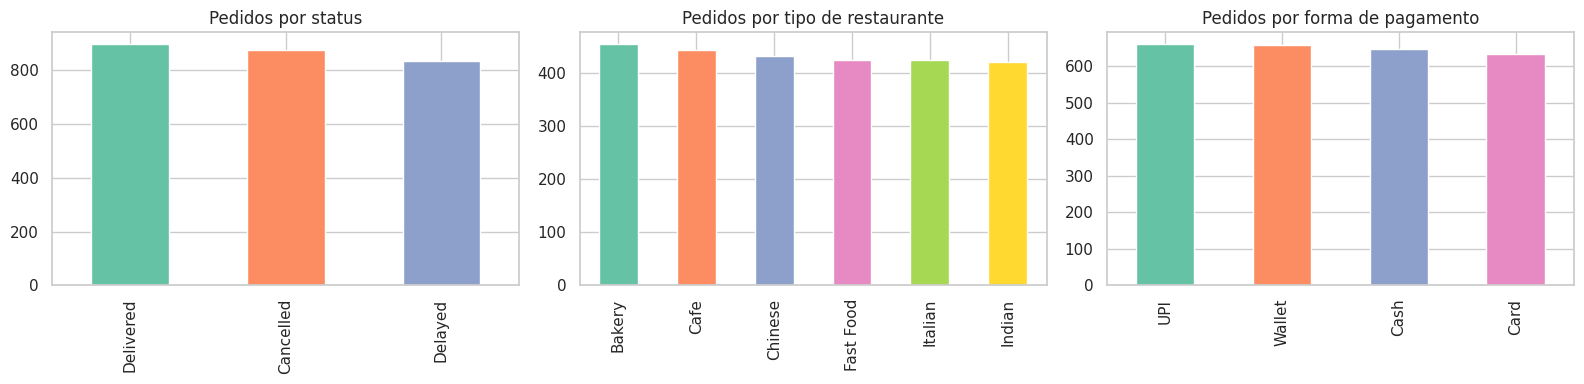

order_status
Delivered    34.4
Cancelled    33.6
Delayed      32.0
Name: proportion, dtype: float64 % por status


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))   # cria 1 figura com 3 gráficos lado a lado (1 linha, 3 colunas)

df["order_status"].value_counts().plot(kind="bar", ax=axes[0], color=sns.color_palette("Set2"))
# value_counts(): conta quantos pedidos existem em cada status; .plot(kind="bar"): desenha como gráfico de barras no 1º espaço (axes[0])
axes[0].set_title("Pedidos por status")
axes[0].set_xlabel("")                             # remove o rótulo do eixo X (fica poluído sem necessidade)

df["restaurant_type"].value_counts().plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2"))
axes[1].set_title("Pedidos por tipo de restaurante")
axes[1].set_xlabel("")

df["payment_method"].value_counts().plot(kind="bar", ax=axes[2], color=sns.color_palette("Set2"))
axes[2].set_title("Pedidos por forma de pagamento")
axes[2].set_xlabel("")

plt.tight_layout()                                 # ajusta os espaçamentos para os 3 gráficos não ficarem espremidos/sobrepostos
plt.show()                                         # renderiza a figura na tela

print(df["order_status"].value_counts(normalize=True).round(3) * 100, "% por status")
# normalize=True faz value_counts() devolver proporção (0 a 1) em vez de contagem; *100 transforma em porcentagem


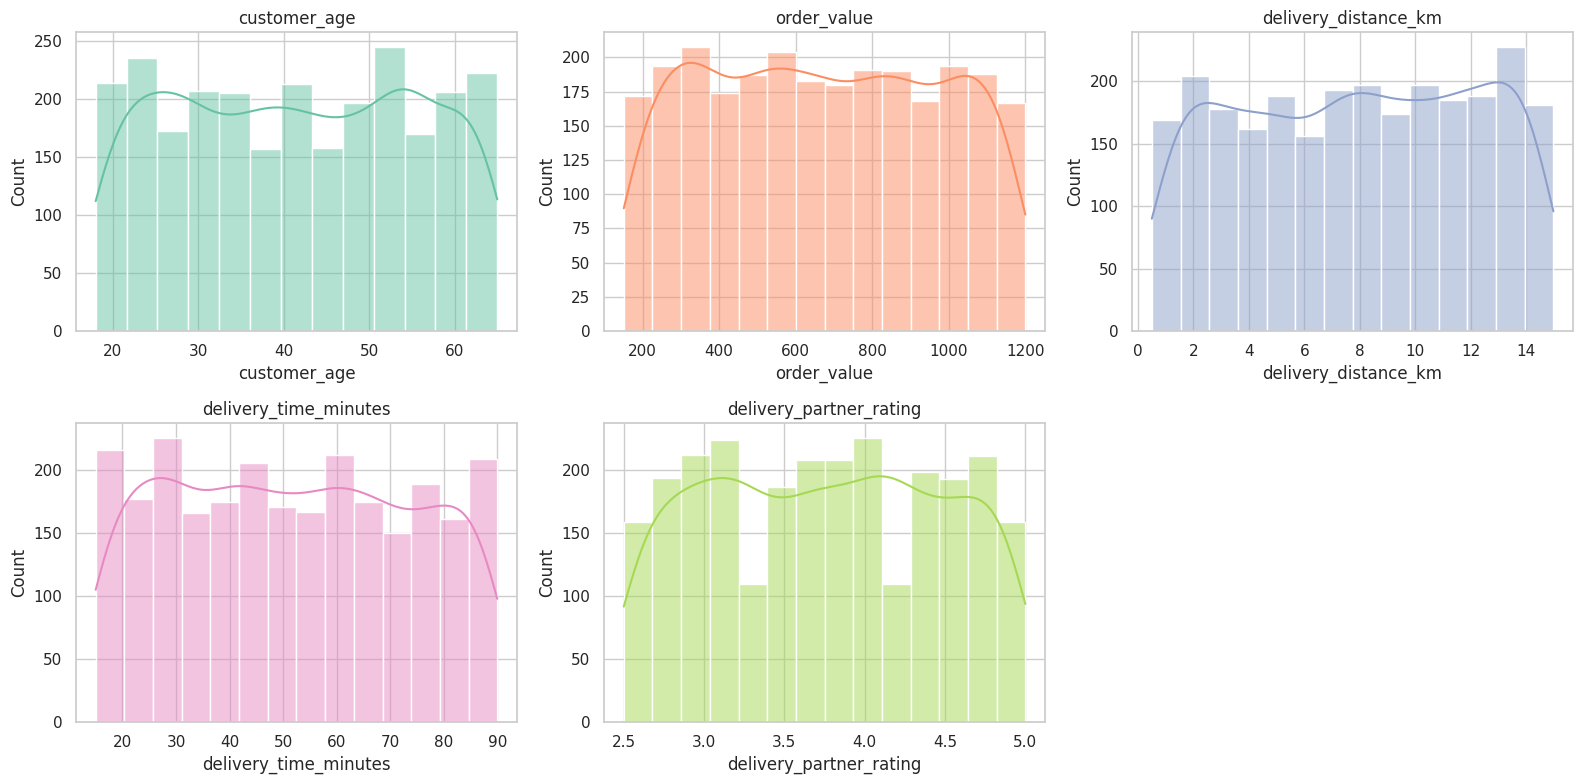

,count,mean,std,min,25%,50%,75%,max
customer_age,2600.0,41.492308,13.977196,18.0,29.0000,41.000,54.00,65.00
order_value,2600.0,670.293873,300.767326,150.9,406.4025,667.580,927.48,1199.78
delivery_distance_km,2600.0,7.886800,4.211332,0.5,4.2075,7.965,11.59,14.99
delivery_time_minutes,2600.0,51.748462,21.987540,15.0,32.0000,51.000,70.00,90.00
delivery_partner_rating,2600.0,3.749577,0.721153,2.5,3.1000,3.800,4.40,5.00


In [ ]:
# Distribuições das variáveis numéricas
num_cols = ["customer_age", "order_value", "delivery_distance_km",
            "delivery_time_minutes", "delivery_partner_rating"]
# lista com os nomes das 5 colunas numéricas que vamos analisar repetidamente no notebook

fig, axes = plt.subplots(2, 3, figsize=(16, 8))    # cria uma grade de 2 linhas x 3 colunas = 6 espaços para gráficos (só vamos usar 5)
axes = axes.flatten()                              # transforma a grade 2x3 em uma lista simples de 6 posições, mais fácil de indexar
for i, col in enumerate(num_cols):                 # percorre cada coluna numérica, junto com seu índice (0,1,2,3,4)
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette("Set2")[i])
    # histplot desenha um histograma (barras de frequência); kde=True adiciona uma curva suavizada de densidade por cima
    axes[i].set_title(col)                         # título do gráfico = nome da coluna
axes[-1].axis("off")                               # desliga o 6º espaço (sobrou vazio, pois só temos 5 colunas)
plt.tight_layout()
plt.show()

df[num_cols].describe().T
# describe() traz média, desvio padrão, mínimo, máximo etc.; .T "transpõe" a tabela (coloca as colunas nas linhas, fica mais fácil de ler)


In [ ]:
# Médias das variáveis numéricas por status do pedido — a leitura "tradicional"
tabela_tradicional = df.groupby("order_status")[num_cols].mean().round(2)
# groupby("order_status"): separa os pedidos em 3 grupos (Delivered/Cancelled/Delayed);
# [num_cols].mean(): calcula a média de cada coluna numérica dentro de cada grupo; round(2): arredonda para 2 casas decimais
print("Médias por status do pedido:")
tabela_tradicional                                 # exibe a tabela resultante


Médias por status do pedido:


,customer_age,order_value,delivery_distance_km,delivery_time_minutes,delivery_partner_rating
order_status,,,,,
Cancelled,41.24,666.37,7.88,51.68,3.73
Delayed,41.68,666.81,7.94,52.30,3.77
Delivered,41.57,677.36,7.85,51.30,3.75


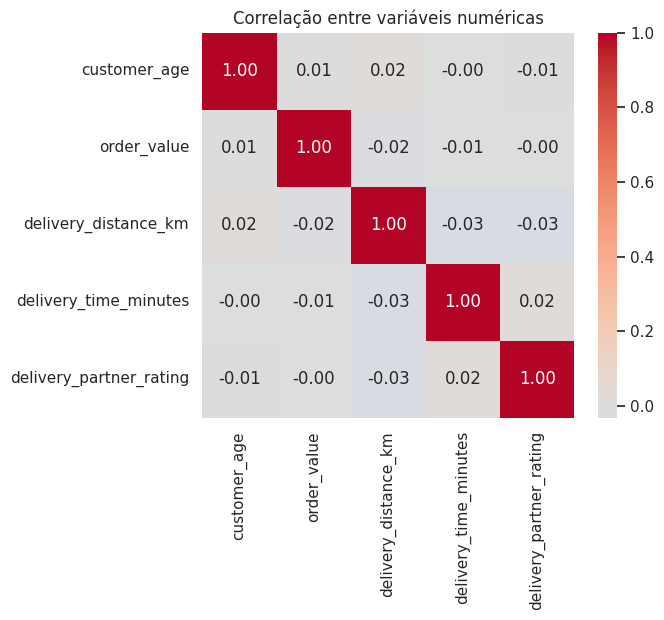

In [ ]:
# Matriz de correlação entre as variáveis numéricas
plt.figure(figsize=(6, 5))                          # abre uma nova figura com esse tamanho
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
# df[num_cols].corr(): calcula a correlação entre cada par de colunas numéricas (varia de -1 a 1)
# annot=True: escreve o número dentro de cada célula; cmap="coolwarm": azul p/ negativo, vermelho p/ positivo
# center=0: garante que o branco do mapa de cor fique exatamente no zero; fmt=".2f": 2 casas decimais
plt.title("Correlação entre variáveis numéricas")
plt.show()


**Leitura tradicional:** olhando as médias por status e a matriz de correlação, os valores são muito parecidos entre "Delivered", "Cancelled" e "Delayed", e as correlações entre variáveis numéricas são próximas de zero. Um analista tradicional, olhando só isso, já desconfiaria que essas variáveis não diferenciam bem os status — mas uma tabela de médias não prova estatisticamente essa suspeita, e não é capaz de descobrir agrupamentos que não sejam as categorias já existentes no dataset (status, tipo de restaurante etc.). É exatamente essa limitação que o par "inteligente" ataca.


## 1.2 — Par Inteligente: segmentação automática com Clusterização (K-Means)

Em vez de partirmos de categorias já prontas (status, tipo de restaurante...), deixamos um algoritmo **descobrir sozinho** se existem grupos naturais de pedidos, olhando apenas para os números (idade, valor, distância, tempo de entrega, nota do entregador).


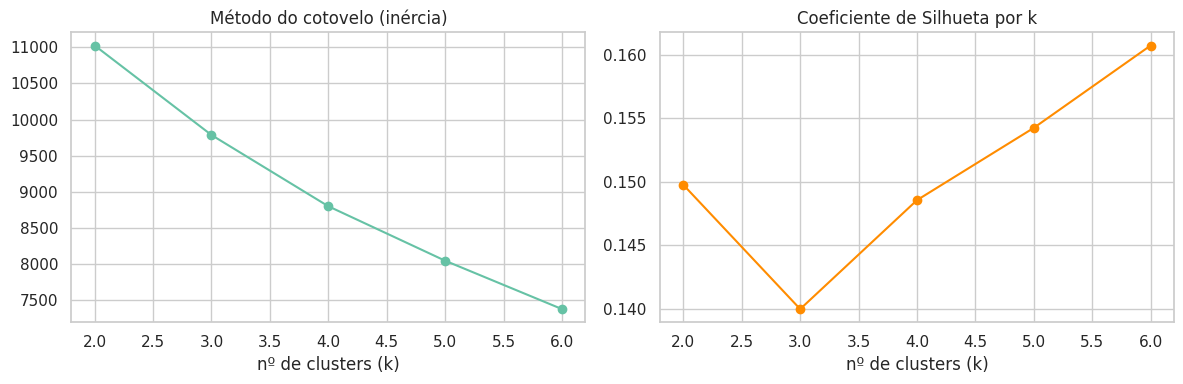

k=2 -> silhouette=0.150
k=3 -> silhouette=0.140
k=4 -> silhouette=0.149
k=5 -> silhouette=0.154
k=6 -> silhouette=0.161


In [ ]:
# Padronização (K-Means é sensível à escala das variáveis)
scaler = StandardScaler()                           # cria o "padronizador": vai deixar cada coluna com média 0 e desvio padrão 1
X_cluster = scaler.fit_transform(df[num_cols])
# fit_transform: aprende a média/desvio de cada coluna (fit) e já aplica a transformação (transform) de uma vez
# Isso é necessário porque, sem padronizar, uma coluna com números grandes (ex.: order_value) dominaria o cálculo de distância do K-Means

# Método do cotovelo (inércia) + Silhouette para escolher o número de clusters
inercias, silhouettes = [], []                      # listas vazias para guardar os resultados de cada tentativa de k
faixa_k = range(2, 7)                               # vamos testar k = 2, 3, 4, 5 e 6 clusters

for k in faixa_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    # n_clusters=k: quantos grupos formar; random_state=42: trava a aleatoriedade (resultado sempre igual ao rodar de novo);
    # n_init=10: roda o algoritmo 10 vezes com pontos de partida diferentes e fica com o melhor resultado
    labels = km.fit_predict(X_cluster)              # treina o modelo e já devolve, para cada pedido, a qual cluster ele pertence
    inercias.append(km.inertia_)                    # inertia_: soma das distâncias de cada ponto até o centro do seu cluster (quanto menor, mais compacto)
    silhouettes.append(silhouette_score(X_cluster, labels))   # calcula o quão bem separados ficaram os clusters com esse k

fig, axes = plt.subplots(1, 2, figsize=(12, 4))     # 1 linha, 2 gráficos lado a lado
axes[0].plot(list(faixa_k), inercias, marker="o")   # gráfico de linha: eixo X = número de clusters, eixo Y = inércia
axes[0].set_title("Método do cotovelo (inércia)")
axes[0].set_xlabel("nº de clusters (k)")

axes[1].plot(list(faixa_k), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Coeficiente de Silhueta por k")
axes[1].set_xlabel("nº de clusters (k)")
plt.tight_layout()
plt.show()

for k, s in zip(faixa_k, silhouettes):              # zip: percorre as duas listas (faixa_k e silhouettes) em paralelo, par a par
    print(f"k={k} -> silhouette={s:.3f}")           # imprime o valor da silhueta obtido para cada k testado


**Como interpretar a Silhueta:** varia de -1 a 1. Valores acima de 0,5 indicam clusters bem separados; entre 0,25 e 0,5, clusters fracos/parcialmente sobrepostos; abaixo de 0,25, praticamente não há estrutura de agrupamento real nos dados. Vamos escolher k=3 (por ser interpretável e alinhado às 3 categorias de status) e já adiantamos: o valor da silhueta vai ficar baixo — isso também é uma informação relevante, não um erro do código.


Silhouette final (k=3): 0.140


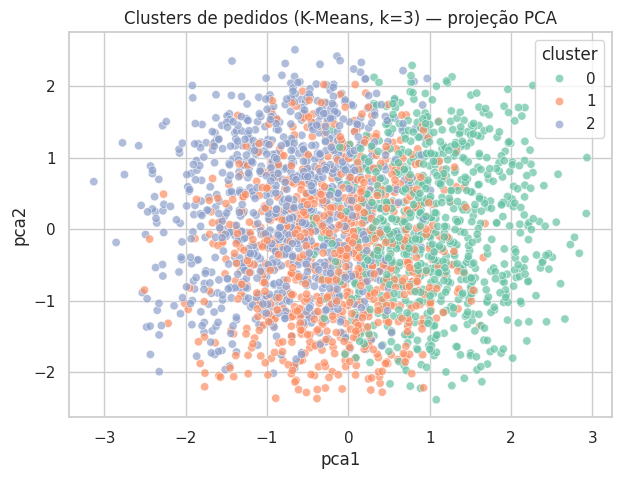

Variância explicada pelas 2 componentes: 41.4%


In [ ]:
k_escolhido = 3                                      # decidimos usar 3 clusters (justificativa no texto acima)
kmeans = KMeans(n_clusters=k_escolhido, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_cluster)        # treina o modelo final e já grava, para cada pedido, o número do cluster (0, 1 ou 2)

sil_final = silhouette_score(X_cluster, df["cluster"])
print(f"Silhouette final (k={k_escolhido}): {sil_final:.3f}")

# Visualização em 2D via PCA (reduz as 5 dimensões numéricas a 2 componentes principais)
pca = PCA(n_components=2, random_state=42)           # PCA vai combinar as 5 colunas numéricas em apenas 2 "eixos" novos, para dar pra desenhar
componentes = pca.fit_transform(X_cluster)           # aplica a redução de dimensão nos dados já padronizados
df["pca1"], df["pca2"] = componentes[:, 0], componentes[:, 1]
# guarda as duas novas coordenadas (pca1 = 1ª coluna do resultado, pca2 = 2ª coluna) como novas colunas do DataFrame

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="pca1", y="pca2", hue="cluster", palette="Set2", alpha=0.7)
# scatterplot: gráfico de pontos; hue="cluster" colore cada ponto de acordo com o cluster a que pertence; alpha=0.7 deixa os pontos semitransparentes
plt.title(f"Clusters de pedidos (K-Means, k={k_escolhido}) — projeção PCA")
plt.show()

print(f"Variância explicada pelas 2 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%")
# explained_variance_ratio_: quanto da informação original (das 5 colunas) esses 2 eixos conseguiram preservar — quanto maior, mais fiel é o gráfico


In [ ]:
# Perfil de cada cluster (o que caracteriza cada grupo encontrado pelo algoritmo)
perfil_clusters = df.groupby("cluster")[num_cols].mean().round(2)
# separa os pedidos pelo cluster e calcula a média de cada variável numérica dentro de cada grupo
perfil_clusters["nº de pedidos"] = df["cluster"].value_counts().sort_index()
# adiciona uma coluna extra com quantos pedidos caíram em cada cluster (sort_index garante a ordem 0,1,2)
print("Perfil de cada cluster:")
display(perfil_clusters)                             # display: mostra a tabela formatada (equivalente a só escrever o nome da variável)

# O cluster tem relação com o status do pedido, ou é um agrupamento independente?
print("\nDistribuição de status dentro de cada cluster (%):")
display((pd.crosstab(df["cluster"], df["order_status"], normalize="index") * 100).round(1))
# crosstab: cruza cluster x status, contando quantos pedidos há em cada combinação;
# normalize="index": transforma em porcentagem dentro de cada linha (cada cluster soma 100%); *100 e round(1) só formatam a exibição


Perfil de cada cluster:


,customer_age,order_value,delivery_distance_km,delivery_time_minutes,delivery_partner_rating,nº de pedidos
cluster,,,,,,
0,42.65,674.62,10.79,44.76,3.10,791
1,41.33,619.87,10.37,57.22,4.38,832
2,40.70,709.74,3.42,52.74,3.74,977



Distribuição de status dentro de cada cluster (%):


order_status,Cancelled,Delayed,Delivered
cluster,,,
0,34.4,32.5,33.1
1,33.7,32.1,34.3
2,32.9,31.5,35.6


**Comparação do par (Descritiva):**

- A silhueta ficou baixa (tipicamente ~0,14–0,16), o que indica clusters **fracos e sobrepostos** — o K-Means até consegue separar grupos com perfis numéricos levemente diferentes (ex.: um grupo com entregadores mais bem avaliados, outro com pedidos de maior distância), mas **nenhum desses grupos se associa ao status do pedido** (as proporções de Delivered/Cancelled/Delayed são praticamente iguais em todos os clusters).
- **Ganho real da abordagem inteligente:** ela não depende de hipóteses prévias — descobre sozinha se existe estrutura nos dados — e permite **quantificar** o quão fraca é essa estrutura (silhueta), algo que a tabela de médias tradicional não oferece.
- **Limite:** neste dataset específico, a IA descritiva confirma, com números, a mesma suspeita que a análise tradicional já levantava visualmente — ou seja, aqui o ganho foi de **rigor e automação**, não de descoberta de um padrão novo e acionável.


---
# 2. Análise Preditiva

**Objetivo:** prever o `order_status` (Delivered / Cancelled / Delayed) a partir das demais variáveis — e testar, de forma honesta, se modelos de Machine Learning realmente melhoram essa previsão em relação a uma abordagem tradicional.


## 2.1 — Par Tradicional: regra de negócio + testes estatísticos simples

Um analista tradicional normalmente parte de **hipóteses de bom senso** ("pedidos de longa distância atrasam mais", "pagamento em dinheiro cancela mais") e de uma **regra fixa**. Vamos formalizar isso de duas formas:

1. Um classificador ingênuo (baseline): sempre prever a classe mais frequente.
2. Uma regra de negócio manual baseada em limiares.
3. Testes estatísticos (Qui-quadrado e ANOVA) para checar se essas hipóteses realmente têm respaldo nos dados.


In [ ]:
# Baseline 1: sempre prever a classe majoritária
classe_majoritaria = df["order_status"].value_counts().idxmax()
# value_counts(): conta pedidos por status; idxmax(): pega o NOME do status com maior contagem (o mais frequente)
acc_baseline = (df["order_status"] == classe_majoritaria).mean()
# compara cada linha com a classe majoritária (True/False) e tira a média — como True=1 e False=0, a média vira a % de acerto
print(f"Classe majoritária: {classe_majoritaria}")
print(f"Acurácia do baseline 'sempre prever a classe majoritária': {acc_baseline:.3f}")


Classe majoritária: Delivered
Acurácia do baseline 'sempre prever a classe majoritária': 0.344


In [ ]:
# Baseline 2: regra de negócio manual (hipótese de bom senso)
# Hipótese: distância longa (>10km) tende a atrasar; distância curta tende a ser entregue
def regra_de_negocio(linha):                         # função que recebe UMA linha da tabela e devolve um status "chutado"
    if linha["delivery_distance_km"] > 10:
        return "Delayed"                             # se a distância é maior que 10km, aposta que atrasou
    elif linha["delivery_distance_km"] < 3:
        return "Delivered"                           # se a distância é menor que 3km, aposta que foi entregue
    else:
        return "Cancelled"                           # nos demais casos (entre 3 e 10km), aposta que foi cancelado

pred_regra = df.apply(regra_de_negocio, axis=1)
# df.apply(..., axis=1): aplica a função linha por linha (axis=1 = "percorrer por linha", não por coluna) e junta os resultados numa lista
acc_regra = (pred_regra == df["order_status"]).mean()
# compara o "chute" da regra com o status real, linha a linha, e calcula a % de acerto (igual ao baseline anterior)
print(f"Acurácia da regra de negócio manual: {acc_regra:.3f}")


Acurácia da regra de negócio manual: 0.340


In [ ]:
# As hipóteses de bom senso realmente se sustentam estatisticamente?
# Qui-quadrado para variáveis categóricas x order_status
print("### Teste Qui-quadrado (associação com order_status) ###")
for cat in ["restaurant_type", "payment_method", "dia_semana"]:   # repete o teste para cada uma dessas 3 colunas categóricas
    tabela = pd.crosstab(df[cat], df["order_status"])
    # crosstab: monta uma tabela de contingência — quantos pedidos existem em cada combinação de (categoria) x (status)
    chi2, p, dof, esperado = chi2_contingency(tabela)
    # chi2_contingency roda o teste Qui-quadrado sobre essa tabela e devolve: a estatística chi2, o p-valor,
    # os graus de liberdade (dof) e a tabela de valores "esperados" se não houvesse nenhuma associação
    significativo = "SIM (p < 0.05)" if p < 0.05 else "não (p >= 0.05)"
    # convenção estatística padrão: p-valor menor que 0,05 é considerado "estatisticamente significativo"
    print(f"{cat:18s} -> chi2={chi2:6.2f}  p-valor={p:.4f}  associação significativa? {significativo}")

print("\n### Teste ANOVA (diferença de médias entre grupos de status) ###")
for col in num_cols:                                             # repete o teste para cada coluna numérica
    grupos = [g[col].values for _, g in df.groupby("order_status")]
    # separa os valores da coluna 'col' em 3 grupos (um por status) — necessário porque o ANOVA compara grupos entre si
    f_stat, p = f_oneway(*grupos)
    # f_oneway compara as médias dos 3 grupos; o "*" desempacota a lista de grupos como argumentos separados da função
    significativo = "SIM (p < 0.05)" if p < 0.05 else "não (p >= 0.05)"
    print(f"{col:24s} -> F={f_stat:6.3f}  p-valor={p:.4f}  diferença significativa? {significativo}")


### Teste Qui-quadrado (associação com order_status) ###
restaurant_type    -> chi2= 10.63  p-valor=0.3872  associação significativa? não (p >= 0.05)
payment_method     -> chi2=  9.39  p-valor=0.1529  associação significativa? não (p >= 0.05)
dia_semana         -> chi2= 11.22  p-valor=0.5100  associação significativa? não (p >= 0.05)

### Teste ANOVA (diferença de médias entre grupos de status) ###
customer_age             -> F= 0.233  p-valor=0.7924  diferença significativa? não (p >= 0.05)
order_value              -> F= 0.377  p-valor=0.6857  diferença significativa? não (p >= 0.05)
delivery_distance_km     -> F= 0.097  p-valor=0.9074  diferença significativa? não (p >= 0.05)
delivery_time_minutes    -> F= 0.449  p-valor=0.6381  diferença significativa? não (p >= 0.05)
delivery_partner_rating  -> F= 0.669  p-valor=0.5121  diferença significativa? não (p >= 0.05)


**Leitura tradicional:** nenhuma variável passou nos testes de significância (todos os p-valores ficaram bem acima de 0,05). Isso quer dizer, estatisticamente, que **não há evidência de associação** entre essas variáveis e o status do pedido. Uma regra de negócio manual, mesmo bem-intencionada, está apostando em um padrão que os dados não sustentam — e é exatamente por isso que sua acurácia (~33%) não fica muito diferente da de simplesmente "chutar" a classe mais comum.


## 2.2 — Par Inteligente: Machine Learning (Regressão Logística, Random Forest, Gradient Boosting)

Agora damos à IA a chance de encontrar, sozinha, combinações não-óbvias entre as variáveis que um humano dificilmente enxergaria numa tabela.


In [ ]:
# Preparação dos dados: codificação de variáveis categóricas
df_ml = df.copy()                                    # cria uma cópia do DataFrame, para não bagunçar o 'df' original usado nas seções anteriores

le_restaurante = LabelEncoder()                      # LabelEncoder transforma texto em números (ex.: "Bakery"->0, "Cafe"->1, ...)
df_ml["restaurant_type_cod"] = le_restaurante.fit_transform(df_ml["restaurant_type"])
# fit_transform: aprende quais categorias existem e já converte a coluna inteira para números

le_pagamento = LabelEncoder()
df_ml["payment_method_cod"] = le_pagamento.fit_transform(df_ml["payment_method"])   # mesma ideia, para a forma de pagamento

le_status = LabelEncoder()
y = le_status.fit_transform(df_ml["order_status"])   # transforma a variável-alvo (o que queremos prever) em números: 0, 1 ou 2
print("Classes:", list(le_status.classes_))          # le_status.classes_ guarda a ordem original dos nomes (para saber o que 0,1,2 significam)

features = ["customer_age", "restaurant_type_cod", "order_value", "delivery_distance_km",
            "delivery_time_minutes", "payment_method_cod", "delivery_partner_rating",
            "mes", "fim_de_semana"]
# lista de colunas que o modelo vai usar como "pistas" para tentar prever o status
X = df_ml[features]                                  # X = matriz de entrada do modelo (todas as colunas de 'features')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
# separa 75% dos pedidos para treino e 25% para teste; stratify=y garante que a proporção das 3 classes seja mantida nos dois conjuntos;
# random_state=42 trava a aleatoriedade da divisão, para o resultado ser sempre igual ao rodar de novo
print(f"Treino: {X_train.shape[0]} pedidos | Teste: {X_test.shape[0]} pedidos")


Classes: ['Cancelled', 'Delayed', 'Delivered']
Treino: 1950 pedidos | Teste: 650 pedidos


In [ ]:
# Treinamos 3 modelos diferentes e comparamos com o baseline tradicional
# (a Regressão Logística recebe as variáveis padronizadas, dentro de um Pipeline, para convergir bem)
from sklearn.pipeline import make_pipeline           # make_pipeline encadeia etapas (ex.: primeiro padronizar, depois treinar) em um único objeto

modelos = {
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    # Pipeline: 1º padroniza as variáveis (StandardScaler), 2º treina a Regressão Logística; max_iter=2000 dá mais "tentativas" para o modelo convergir
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    # n_estimators=300: usa 300 árvores de decisão combinadas; max_depth=8: limita a profundidade de cada árvore (evita "decorar" demais os dados)
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    # também combina várias árvores, mas treina cada nova árvore para corrigir os erros das anteriores
}

resultados = []                                      # vai guardar um dicionário de métricas para cada modelo testado
previsoes = {}                                       # vai guardar as previsões de cada modelo no conjunto de teste (para usar mais adiante)

for nome, modelo in modelos.items():                 # percorre cada par (nome do modelo, objeto do modelo) do dicionário acima
    modelo.fit(X_train, y_train)                     # treina o modelo usando apenas os dados de treino
    pred = modelo.predict(X_test)                    # usa o modelo treinado para prever os status dos pedidos de teste (que ele nunca viu)
    previsoes[nome] = pred                           # guarda essas previsões, indexadas pelo nome do modelo

    # validação cruzada (5 folds) para uma estimativa mais robusta da acurácia
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # StratifiedKFold: divide os dados em 5 "fatias" (folds) mantendo a proporção das classes em cada uma; shuffle=True embaralha antes de dividir
    cv_scores = cross_val_score(modelo, X, y, cv=cv, scoring="accuracy")
    # treina e testa o modelo 5 vezes (cada vez usando 4 fatias para treino e 1 para teste) e devolve as 5 acurácias obtidas

    resultados.append({
        "Modelo": nome,
        "Acurácia (teste)": accuracy_score(y_test, pred),           # % de acerto no conjunto de teste único (separado lá em cima)
        "F1-macro (teste)": f1_score(y_test, pred, average="macro"),# média do F1-score das 3 classes, tratando todas com o mesmo peso
        "Acurácia média (5-fold CV)": cv_scores.mean(),              # média das 5 acurácias da validação cruzada
        "Desvio padrão (5-fold CV)": cv_scores.std(),                # o quanto essas 5 acurácias variaram entre si (estabilidade do modelo)
    })

resultados.append({
    "Modelo": "Baseline (classe majoritária)",
    "Acurácia (teste)": acc_baseline,               # reaproveita o valor calculado na seção 2.1
    "F1-macro (teste)": np.nan,                     # não faz sentido calcular F1 para essa regra simples; np.nan = "não se aplica"
    "Acurácia média (5-fold CV)": acc_baseline,
    "Desvio padrão (5-fold CV)": 0.0,               # é sempre a mesma regra fixa, então não varia
})
resultados.append({
    "Modelo": "Regra de negócio manual",
    "Acurácia (teste)": acc_regra,                  # reaproveita o valor calculado na seção 2.1
    "F1-macro (teste)": np.nan,
    "Acurácia média (5-fold CV)": np.nan,
    "Desvio padrão (5-fold CV)": np.nan,
})

tabela_resultados = pd.DataFrame(resultados).round(4)   # transforma a lista de dicionários em uma tabela, arredondada a 4 casas decimais
tabela_resultados


,Modelo,Acurácia (teste),F1-macro (teste),Acurácia média (5-fold CV),Desvio padrão (5-fold CV)
0,Regressão Logística,0.3138,0.2995,0.3273,0.0215
1,Random Forest,0.3108,0.3053,0.3335,0.0188
2,Gradient Boosting,0.3431,0.3393,0.3323,0.0187
3,Baseline (classe majoritária),0.3442,NaN,0.3442,0.0000
4,Regra de negócio manual,0.3400,NaN,NaN,NaN


**Como ler essa tabela:** com 3 classes praticamente equilibradas, um modelo que não aprendeu nada útil tende a acertar perto de 33% (1 em 3, no chute aleatório). Compare a acurácia de cada modelo de ML com o baseline e com esse valor de referência antes de comemorar qualquer número.


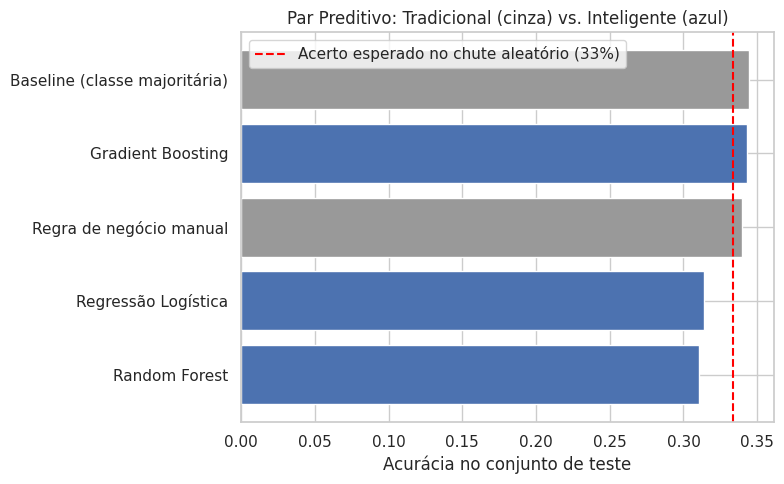

In [ ]:
# Gráfico comparando os pares (tradicional x inteligente)
plt.figure(figsize=(8, 5))
ordem = tabela_resultados.sort_values("Acurácia (teste)", ascending=True)
# ordena a tabela da menor para a maior acurácia, para o gráfico de barras horizontais ficar em ordem crescente
cores = ["#999999" if "Baseline" in m or "manual" in m else "#4C72B0" for m in ordem["Modelo"]]
# lista de cores: cinza (#999999) para os métodos tradicionais (Baseline/regra manual), azul (#4C72B0) para os modelos de ML
plt.barh(ordem["Modelo"], ordem["Acurácia (teste)"], color=cores)   # barh = gráfico de barras horizontais
plt.axvline(1/3, color="red", linestyle="--", label="Acerto esperado no chute aleatório (33%)")
# axvline: desenha uma linha vertical tracejada em x=1/3, como referência visual do "chute aleatório" com 3 classes
plt.xlabel("Acurácia no conjunto de teste")
plt.title("Par Preditivo: Tradicional (cinza) vs. Inteligente (azul)")
plt.legend()                                         # mostra a legenda (explicando a linha vermelha tracejada)
plt.tight_layout()
plt.show()


## Matriz de confusão — o que ela mostra e como interpretar

A matriz de confusão cruza o que o modelo **previu** com o que **de fato aconteceu**. Cada linha é a classe real; cada coluna é a classe prevista. Na diagonal principal ficam os acertos; fora da diagonal, os erros — e o tipo de erro importa (ex.: prever "Delivered" quando era "Cancelled" é um erro operacionalmente diferente de confundir "Delayed" com "Cancelled").

Para cada classe, também calculamos (com a lógica de "essa classe" vs. "todas as outras"):
- **VP (Verdadeiro Positivo):** o modelo previu essa classe e acertou.
- **FP (Falso Positivo):** o modelo previu essa classe, mas era outra — "alarme falso".
- **FN (Falso Negativo):** era essa classe, mas o modelo previu outra — "passou batido".
- **VN (Verdadeiro Negativo):** não era essa classe e o modelo, corretamente, não previu essa classe.

A partir desses quatro números vêm as métricas de cada classe:
- **Precisão** = VP / (VP + FP) → das vezes que o modelo disse "é essa classe", quantas vezes acertou.
- **Recall (sensibilidade)** = VP / (VP + FN) → dos casos reais dessa classe, quantos o modelo conseguiu capturar.
- **F1-score** = média harmônica entre precisão e recall (equilibra os dois).


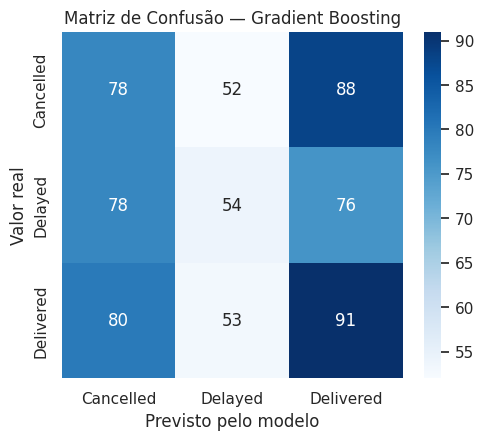

Acurácia geral: 34.3%  |  Acerto esperado no chute aleatório: 33.3%

Classe 'Cancelled':
  VP=  78  FP= 158  FN= 140  VN= 274
  Precisão=33.1%  |  Recall=35.8%  |  F1-score=34.4%

Classe 'Delayed':
  VP=  54  FP= 105  FN= 154  VN= 337
  Precisão=34.0%  |  Recall=26.0%  |  F1-score=29.4%

Classe 'Delivered':
  VP=  91  FP= 164  FN= 133  VN= 262
  Precisão=35.7%  |  Recall=40.6%  |  F1-score=38.0%

⚠️ Diagnóstico: a acurácia do modelo está muito próxima do chute aleatório.
Isso indica que as variáveis disponíveis não têm poder preditivo relevante
sobre essa variável-alvo — não é um problema de código, é um problema de SINAL nos dados.


In [ ]:
def explicar_matriz_confusao(y_real, y_pred, nomes_classes, titulo="Modelo"):
    '''Plota a matriz de confusão e imprime a explicação em português, classe a classe.'''
    cm = confusion_matrix(y_real, y_pred)
    # confusion_matrix cruza valores reais (y_real) com valores previstos (y_pred) e devolve uma matriz de contagens (linhas=real, colunas=previsto)

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=nomes_classes, yticklabels=nomes_classes)
    # heatmap desenha a matriz como um mapa de calor; annot=True escreve o número em cada célula; fmt="d" formata como inteiro;
    # xticklabels/yticklabels: usa os nomes reais das classes (Cancelled/Delayed/Delivered) em vez de 0,1,2
    plt.xlabel("Previsto pelo modelo")
    plt.ylabel("Valor real")
    plt.title(f"Matriz de Confusão — {titulo}")
    plt.show()

    n_classes = len(nomes_classes)                   # quantas classes existem (3, neste projeto)
    acuracia = accuracy_score(y_real, y_pred)        # % geral de acertos do modelo
    acerto_aleatorio = 1 / n_classes                 # o que se esperaria acertar só no chute, com n_classes igualmente prováveis

    print(f"Acurácia geral: {acuracia:.1%}  |  Acerto esperado no chute aleatório: {acerto_aleatorio:.1%}\n")

    mcm = multilabel_confusion_matrix(y_real, y_pred)
    # em vez de UMA matriz 3x3, gera uma matriz 2x2 (Verdadeiro/Falso Positivo/Negativo) PARA CADA classe, no esquema "essa classe vs. as outras"
    for i, classe in enumerate(nomes_classes):       # percorre cada classe, junto com seu índice na matriz
        vn, fp, fn, vp = mcm[i].ravel()
        # mcm[i] é a matriz 2x2 da classe 'i'; .ravel() "achata" essa matriz 2x2 em uma lista de 4 números, na ordem VN, FP, FN, VP
        precisao = vp / (vp + fp) if (vp + fp) > 0 else 0
        # precisão = acertos dessa classe / tudo que o modelo chamou dessa classe (evita dividir por zero se vp+fp=0)
        recall = vp / (vp + fn) if (vp + fn) > 0 else 0
        # recall = acertos dessa classe / tudo que realmente era dessa classe
        f1 = (2 * precisao * recall / (precisao + recall)) if (precisao + recall) > 0 else 0
        # F1-score = média harmônica entre precisão e recall (penaliza mais quando um dos dois é muito baixo)
        print(f"Classe '{classe}':")
        print(f"  VP={vp:4d}  FP={fp:4d}  FN={fn:4d}  VN={vn:4d}")
        print(f"  Precisão={precisao:.1%}  |  Recall={recall:.1%}  |  F1-score={f1:.1%}\n")

    if acuracia <= acerto_aleatorio + 0.05:          # se a acurácia está no máximo 5 pontos percentuais acima do chute aleatório...
        print("⚠️ Diagnóstico: a acurácia do modelo está muito próxima do chute aleatório.")
        print("Isso indica que as variáveis disponíveis não têm poder preditivo relevante")
        print("sobre essa variável-alvo — não é um problema de código, é um problema de SINAL nos dados.")
    else:                                             # caso contrário, o modelo está de fato aprendendo algo útil
        print("✅ Diagnóstico: o modelo está acertando significativamente mais do que o chute aleatório.")

# Aplicando ao melhor modelo (Gradient Boosting, geralmente o de maior acurácia média em CV)
melhor_modelo = "Gradient Boosting"
explicar_matriz_confusao(y_test, previsoes[melhor_modelo], le_status.classes_, titulo=melhor_modelo)
# chama a função criada acima, passando: valores reais do teste, previsões desse modelo, e os nomes originais das classes


In [ ]:
# Relatório de classificação completo (precision/recall/f1 por classe, via sklearn)
print(classification_report(y_test, previsoes[melhor_modelo], target_names=le_status.classes_))
# classification_report calcula automaticamente precisão, recall e F1 de cada classe (os mesmos números da função acima,
# só que prontos do scikit-learn) e ainda soma médias gerais (accuracy, macro avg, weighted avg) no final


              precision    recall  f1-score   support

   Cancelled       0.33      0.36      0.34       218
     Delayed       0.34      0.26      0.29       208
   Delivered       0.36      0.41      0.38       224

    accuracy                           0.34       650
   macro avg       0.34      0.34      0.34       650
weighted avg       0.34      0.34      0.34       650



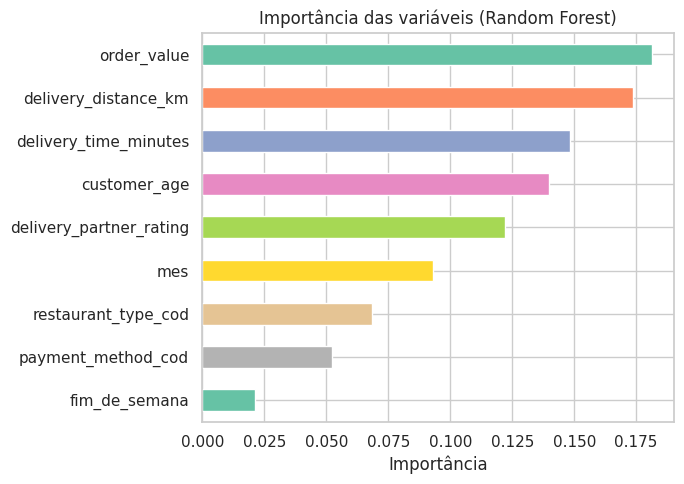

order_value                0.181204
delivery_distance_km       0.173601
delivery_time_minutes      0.148201
customer_age               0.139774
delivery_partner_rating    0.122204
mes                        0.093217
restaurant_type_cod        0.068602
payment_method_cod         0.052095
fim_de_semana              0.021102
dtype: float64

In [ ]:
# Importância de cada variável para o modelo Random Forest
rf = modelos["Random Forest"]                        # pega o objeto do modelo Random Forest já treinado, guardado no dicionário 'modelos'
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
# feature_importances_: para cada variável, um número (0 a 1) de quanto ela contribuiu para as decisões do modelo;
# pd.Series(..., index=features): junta esses números com o nome de cada variável; sort_values: ordena da mais para a menos importante

plt.figure(figsize=(7, 5))
importancias.plot(kind="barh", color=sns.color_palette("Set2"))   # gráfico de barras horizontais com as importâncias
plt.gca().invert_yaxis()                             # inverte o eixo Y, para a variável mais importante aparecer no topo do gráfico
plt.title("Importância das variáveis (Random Forest)")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

importancias                                         # mostra também a tabela de números (além do gráfico)


**Leitura:** mesmo a variável "mais importante" para o modelo tem uma importância baixa e muito próxima das demais — não existe uma variável que se destaque como uma explicação forte do status do pedido. Isso é consistente com os testes estatísticos da seção 2.1 e com a matriz de confusão: o modelo está distribuindo os erros de forma parecida com o acaso.


### Bônus: um alvo numérico também é imprevisível com essas variáveis?

Testamos o mesmo raciocínio com uma tarefa de **regressão**: prever `delivery_time_minutes` a partir das demais variáveis. Comparamos uma abordagem tradicional (regressão linear simples) com uma inteligente (Random Forest Regressor).


In [ ]:
y_reg = df_ml["delivery_time_minutes"]              # variável-alvo desta tarefa bônus: um número (minutos), não mais uma categoria
features_reg = ["customer_age", "restaurant_type_cod", "order_value",
                "delivery_distance_km", "payment_method_cod", "delivery_partner_rating"]
X_reg = df_ml[features_reg]                          # variáveis de entrada para tentar prever o tempo de entrega

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)
# mesma lógica da divisão treino/teste feita antes, agora para esta tarefa de regressão (não precisa de 'stratify' pois o alvo é numérico)

# Tradicional: sempre prever a média (baseline) + regressão linear simples
pred_media = np.full_like(yr_test, yr_train.mean(), dtype=float)
# np.full_like: cria uma lista do mesmo tamanho de yr_test, preenchida sempre com o mesmo valor: a média do tempo de entrega no treino
# (é o "baseline" mais simples possível para um problema de regressão — "chutar sempre a média")

lin_reg = LinearRegression()                         # modelo de regressão linear tradicional
lin_reg.fit(Xr_train, yr_train)                      # treina o modelo com os dados de treino
pred_lin = lin_reg.predict(Xr_test)                  # gera as previsões para o conjunto de teste

# Inteligente: Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)   # versão do Random Forest para prever números, não categorias
rf_reg.fit(Xr_train, yr_train)
pred_rf = rf_reg.predict(Xr_test)

comparacao_regressao = pd.DataFrame([
    {"Abordagem": "Baseline (média)", "R²": r2_score(yr_test, pred_media),
     "MAE (min)": mean_absolute_error(yr_test, pred_media),
     "RMSE (min)": mean_squared_error(yr_test, pred_media) ** 0.5},
    # R²: quanto da variação do tempo de entrega o modelo explica (1 = perfeito, 0 = igual a chutar a média, negativo = pior que isso)
    # MAE: erro médio absoluto, em minutos; RMSE: parecido, mas penaliza mais os erros grandes (raiz quadrada do erro quadrático médio)
    {"Abordagem": "Regressão Linear (tradicional)", "R²": r2_score(yr_test, pred_lin),
     "MAE (min)": mean_absolute_error(yr_test, pred_lin),
     "RMSE (min)": mean_squared_error(yr_test, pred_lin) ** 0.5},
    {"Abordagem": "Random Forest (inteligente)", "R²": r2_score(yr_test, pred_rf),
     "MAE (min)": mean_absolute_error(yr_test, pred_rf),
     "RMSE (min)": mean_squared_error(yr_test, pred_rf) ** 0.5},
]).round(3)

comparacao_regressao


,Abordagem,R²,MAE (min),RMSE (min)
0,Baseline (média),-0.001,18.777,21.901
1,Regressão Linear (tradicional),-0.011,18.854,22.013
2,Random Forest (inteligente),-0.011,18.812,22.008


**Leitura:** R² próximo de zero (ou até negativo) em todas as abordagens significa que o modelo explica quase nada da variação do tempo de entrega — de novo, o problema não é o algoritmo escolhido, é a ausência de relação estatística entre essas variáveis e o alvo.


## 2.3 — Comparação do Par (Preditiva): a IA melhorou a previsão?

- **Classificação de status:** nenhum modelo de ML superou de forma relevante o baseline de "chutar a classe majoritária" (~33–34%) ou a regra de negócio manual. A diferença entre os modelos fica dentro da margem de ruído estatístico esperada para uma amostra deste tamanho.
- **Regressão de tempo de entrega:** o mesmo padrão se repete — R² ≈ 0 tanto na abordagem tradicional quanto na inteligente.
- **Conclusão honesta:** para este dataset específico, com estas variáveis, **a resposta é não** — a Inteligência Artificial não melhora a previsão, porque **os testes estatísticos da seção 2.1 já mostram que não existe sinal para nenhum algoritmo explorar**. Isso é diferente de dizer "o projeto falhou": é o resultado correto e esperado quando se testa rigorosamente uma hipótese, e é exatamente o tipo de checagem que evita apresentar, em produção, um modelo que parece sofisticado mas que na prática está adivinhando.


---
# 3. Análise Prescritiva

**Objetivo:** transformar os achados em **recomendações de ação** para a operação de delivery.


## 3.1 — Par Tradicional: recomendações por "bom senso"

Olhando só para as médias da seção 1, seria fácil escrever recomendações como estas, que aparecem com frequência em relatórios operacionais:

1. "Pedidos de pagamento em dinheiro cancelam mais → **incentivar pagamento digital**."
2. "Pedidos de fim de semana atrasam mais → **reforçar equipe aos finais de semana**."
3. "O tipo de restaurante 'Bakery' tem mais cancelamentos → **revisar processo da categoria**."

Essas frases *soam* plausíveis e é assim que decisões operacionais costumam ser tomadas no dia a dia — o problema é que nenhuma delas foi checada estatisticamente antes de virar uma ação (e um investimento).


In [ ]:
# Confrontando cada "achismo" tradicional com o teste estatístico correspondente (já calculado na seção 2.1)
checagem = pd.DataFrame([
    {"Recomendação tradicional": "Incentivar pagamento digital (menos dinheiro)",
     "Variável testada": "payment_method", "Suportada por evidência estatística?": "Não (p ≥ 0,05)"},
    {"Recomendação tradicional": "Reforçar equipe nos finais de semana",
     "Variável testada": "fim_de_semana / dia_semana", "Suportada por evidência estatística?": "Não (p ≥ 0,05)"},
    {"Recomendação tradicional": "Revisar processo da categoria 'Bakery'",
     "Variável testada": "restaurant_type", "Suportada por evidência estatística?": "Não (p ≥ 0,05)"},
])
# monta manualmente uma tabela de 3 linhas, cada uma comparando uma recomendação "de bom senso" com o resultado do teste estatístico já feito
checagem


,Recomendação tradicional,Variável testada,Suportada por evidência estatística?
0,Incentivar pagamento digital (menos dinheiro),payment_method,"Não (p ≥ 0,05)"
1,Reforçar equipe nos finais de semana,fim_de_semana / dia_semana,"Não (p ≥ 0,05)"
2,Revisar processo da categoria 'Bakery',restaurant_type,"Não (p ≥ 0,05)"


## 3.2 — Par Inteligente: recomendação baseada em evidência estatística + simulação

A abordagem inteligente não tenta "forçar" uma recomendação a partir de um padrão fraco. Ela faz duas coisas que a análise tradicional não faz:

1. **Valida estatisticamente** cada hipótese antes de virar ação (já fizemos isso na seção 2.1).
2. **Simula cenários "e se"** usando o próprio modelo treinado, para checar se mudar uma variável de fato move a previsão.


In [ ]:
# Simulação "e se": e se convertêssemos 100% dos pagamentos em dinheiro para UPI?
# Comparamos a probabilidade média prevista de cancelamento antes e depois da mudança simulada.
indice_cancelado = list(le_status.classes_).index("Cancelled")
# le_status.classes_ guarda a ordem das classes (ex.: ['Cancelled','Delayed','Delivered']); .index("Cancelled") acha em que posição ela está

cenario_real = X_test.copy()                         # copia os dados de teste tal como estão (situação real, sem mudanças)
prob_real = modelos["Gradient Boosting"].predict_proba(cenario_real)[:, indice_cancelado].mean()
# predict_proba devolve, para cada pedido, a probabilidade de cada uma das 3 classes; [:, indice_cancelado] pega só a coluna "Cancelled";
# .mean() tira a média dessas probabilidades entre todos os pedidos de teste

cenario_simulado = X_test.copy()                     # uma segunda cópia, que vamos alterar
cod_upi = le_pagamento.transform(["UPI"])[0]         # descobre qual número o LabelEncoder usou para representar "UPI"
cenario_simulado["payment_method_cod"] = cod_upi
# força TODOS os pedidos desse cenário simulado a terem forma de pagamento = UPI, mantendo todas as outras variáveis iguais
prob_simulada = modelos["Gradient Boosting"].predict_proba(cenario_simulado)[:, indice_cancelado].mean()
# recalcula a probabilidade média de cancelamento, agora nesse cenário hipotético

print(f"Probabilidade média de cancelamento — cenário real:      {prob_real:.1%}")
print(f"Probabilidade média de cancelamento — 100% pagto. UPI:   {prob_simulada:.1%}")
print(f"Variação: {(prob_simulada - prob_real)*100:+.2f} pontos percentuais")
# o "+" dentro do formato ":+.2f" faz aparecer o sinal (+ ou -) explicitamente, para deixar claro se a probabilidade subiu ou desceu


Probabilidade média de cancelamento — cenário real:      33.4%
Probabilidade média de cancelamento — 100% pagto. UPI:   32.5%
Variação: -0.93 pontos percentuais


**Leitura da simulação:** a variação é mínima (poucas frações de ponto percentual) — o modelo confirma que mexer na forma de pagamento **não move de forma relevante** a chance de cancelamento. Ou seja: a recomendação tradicional #1 não resistiria a um teste real antes de virar investimento operacional.

### Recomendação prescritiva final (baseada em evidência)

Como nenhuma variável disponível explica de forma significativa o status do pedido, a recomendação **mais responsável** não é "mexer" em pagamento, dia da semana ou tipo de restaurante — é:

1. **Não investir** em ações operacionais baseadas nas variáveis atuais para reduzir cancelamento/atraso — o retorno esperado, pela evidência disponível, é próximo de zero.
2. **Investir em coletar as variáveis certas**: motivo real do cancelamento (relatado pelo cliente/restaurante), carga de pedidos do entregador no momento, condições de trânsito/clima, tempo de preparo do restaurante. São variáveis operacionalmente plausíveis para explicar atraso/cancelamento e que **não estão presentes neste dataset**.
3. **Reaplicar exatamente este notebook** (o pipeline de pares tradicional × inteligente) assim que essas novas variáveis existirem — a metodologia já está pronta para reuso.


## 3.3 — Comparação do Par (Prescritiva)

- A abordagem tradicional gera recomendações plausíveis, mas **não testadas** — o risco é investir tempo e dinheiro em ações que não têm efeito real.
- A abordagem inteligente usa os mesmos dados para **evitar uma decisão equivocada**, e transforma a ausência de sinal em uma recomendação concreta e acionável (coletar outras variáveis).
- **Aqui está o maior ganho de todo o projeto:** o valor da IA não foi "achar um padrão para agir" — foi **impedir uma ação baseada em um padrão que não existe**, o que também é uma vitória em análise de dados aplicada a negócios.


---
# 4. Síntese final: os 3 pares, lado a lado


In [ ]:
sintese = pd.DataFrame([
    {
        "Tipo de análise": "Descritiva",
        "Abordagem Tradicional": "Estatística manual (médias, contagens, tabelas cruzadas)",
        "Abordagem Inteligente": "Clusterização K-Means + PCA",
        "Métrica comparada": "Silhouette score",
        "Resultado": f"{sil_final:.2f} (clusters fracos)",     # reaproveita a variável calculada na seção 1.2
        "Melhora significativa?": "Não — confirma, com número, o que a tabela já sugeria",
    },
    {
        "Tipo de análise": "Preditiva",
        "Abordagem Tradicional": "Baseline + regra de negócio manual",
        "Abordagem Inteligente": "Regressão Logística / Random Forest / Gradient Boosting",
        "Métrica comparada": "Acurácia (teste) vs. 33% aleatório",
        "Resultado": f"{tabela_resultados.set_index('Modelo').loc[melhor_modelo, 'Acurácia (teste)']:.1%} (melhor modelo)",
        # set_index('Modelo'): usa a coluna 'Modelo' como índice da tabela; .loc[melhor_modelo, 'Acurácia (teste)']: busca a célula específica
        "Melhora significativa?": "Não — dentro da margem do acaso",
    },
    {
        "Tipo de análise": "Prescritiva",
        "Abordagem Tradicional": "Recomendações por bom senso (não testadas)",
        "Abordagem Inteligente": "Testes de significância + simulação de cenário",
        "Métrica comparada": "Variação simulada na probabilidade de cancelamento",
        "Resultado": f"{(prob_simulada - prob_real)*100:+.2f} p.p.",   # reaproveita as variáveis da simulação da seção 3.2
        "Melhora significativa?": "Sim — evita decisão operacional equivocada",
    },
])
sintese                                              # exibe a tabela final, resumindo os 3 pares lado a lado


,Tipo de análise,Abordagem Tradicional,Abordagem Inteligente,Métrica comparada,Resultado,Melhora significativa?
0,Descritiva,"Estatística manual (médias, contagens, tabelas...",Clusterização K-Means + PCA,Silhouette score,0.14 (clusters fracos),"Não — confirma, com número, o que a tabela já ..."
1,Preditiva,Baseline + regra de negócio manual,Regressão Logística / Random Forest / Gradient...,Acurácia (teste) vs. 33% aleatório,34.3% (melhor modelo),Não — dentro da margem do acaso
2,Prescritiva,Recomendações por bom senso (não testadas),Testes de significância + simulação de cenário,Variação simulada na probabilidade de cancelam...,-0.93 p.p.,Sim — evita decisão operacional equivocada


## Conclusão geral

Este projeto não buscou "forçar" um resultado impressionante — buscou **testar, com método, se a Inteligência Artificial melhora a análise** deste conjunto de dados específico. A resposta, com evidência:

- **Descritiva:** ganho pequeno, de rigor e automação (a IA quantifica o que a análise tradicional só sugeria visualmente).
- **Preditiva:** nenhum ganho — os dados disponíveis não contêm sinal estatístico suficiente para prever `order_status` ou `delivery_time_minutes`, e isso foi comprovado tanto por testes estatísticos clássicos quanto pelos modelos de ML.
- **Prescritiva:** o maior ganho do projeto — a IA evita que a empresa tome decisões operacionais caras baseadas em padrões que não existem, e aponta exatamente que dados novos precisam ser coletados.

**Limitação do dataset:** o comportamento estatístico observado (correlações ~0, p-valores altos em todos os testes, acurácia de ML ≈ acaso) é típico de bases de dados **sintéticas geradas de forma aleatória** para fins didáticos, como costuma ocorrer em datasets de prática no Kaggle. Isso não invalida a metodologia — pelo contrário, mostra que ela é capaz de **detectar esse cenário** em vez de mascará-lo com métricas infladas.
